# Text Classification bằng RNN với Keras

Notebook này xây dựng mô hình **phân loại cảm xúc review phim** bằng
**Simple RNN** trong Keras.

- Đầu vào: một review phim bằng tiếng Anh.
- Nhãn `0`: negative.
- Nhãn `1`: positive.
- Dataset: IMDB Movie Reviews có sẵn trong Keras và tự tải ở lần chạy đầu.

## Mục tiêu

1. Hiểu token, vocabulary, sequence và padding.
2. Hiểu Embedding và hidden state của RNN.
3. Xây dựng `Embedding → SimpleRNN → Dense`.
4. Huấn luyện bằng `model.fit()`.
5. Đánh giá Accuracy, Precision, Recall và F1.
6. Dự đoán một câu mới.
7. Lưu và nạp lại model.

> Có thể chạy trên CPU. GPU không bắt buộc.

## 1. Text classification là gì?

Text classification là bài toán gán nhãn cho văn bản.

| Văn bản | Nhãn |
|---|---|
| `This movie was excellent.` | Positive |
| `The story was boring.` | Negative |

Pipeline:

```text
Raw text
   ↓
Tokenization
   ↓
Word IDs
   ↓
Padding
   ↓
Embedding
   ↓
RNN
   ↓
Classification
```

## 2. RNN hoạt động thế nào?

RNN đọc chuỗi theo từng time step. Ở bước $t$, model nhận từ hiện tại
$x_t$ và hidden state trước đó $h_{t-1}$:

$$
h_t = \tanh(W_xx_t + W_hh_{t-1} + b)
$$

Hidden state đóng vai trò như một bộ nhớ tóm tắt các từ đã đọc.

```text
word 1 → h1 → word 2 → h2 → word 3 → h3 → prediction
```

Simple RNN dễ hiểu nhưng có thể gặp vanishing gradient trên chuỗi dài. LSTM và
GRU là các biến thể mạnh hơn.

## 3. Embedding Layer

Máy tính không xử lý trực tiếp từ. Mỗi word ID được biến thành một vector:

```text
word ID 49
    ↓
[0.12, -0.35, ..., 0.41]
```

Nếu vocabulary có 10.000 từ và embedding dimension là 64, embedding matrix có
shape `(10000, 64)`.

## 4. Import thư viện

In [ ]:
import re
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.20.0
Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 5. Siêu tham số

| Tham số | Giá trị | Ý nghĩa |
|---|---:|---|
| `VOCAB_SIZE` | 10.000 | Giữ 10.000 từ phổ biến |
| `MAX_LENGTH` | 200 | Mỗi review có 200 tokens |
| `EMBEDDING_DIM` | 64 | Kích thước vector của mỗi từ |
| `RNN_UNITS` | 64 | Kích thước hidden state |
| `BATCH_SIZE` | 64 | Số review trong một batch |
| `EPOCHS` | 5 | Số lượt qua tập train |

In [ ]:
VOCAB_SIZE = 10_000
MAX_LENGTH = 200
EMBEDDING_DIM = 64
RNN_UNITS = 64
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
VALIDATION_FRACTION = 0.20

## 6. Tải IMDB Dataset

`keras.datasets.imdb.load_data()` tự tải dataset đã tokenized.

- 25.000 reviews train.
- 25.000 reviews test.
- Mỗi review là một list word IDs.

In [ ]:
from keras.datasets import imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Train reviews:", len(x_train))
print("Test reviews:", len(x_test))
print("Số token review đầu:", len(x_train[0]))
print("Nhãn review đầu:", y_train[0])
print("20 word IDs đầu:", x_train[0][:20])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train reviews: 25000
Test reviews: 25000
Số token review đầu: 218
Nhãn review đầu: 1
20 word IDs đầu: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]


## 7. Khảo sát độ dài review

Min: 11
Mean: 238.71364
Median: 178.0
Max: 2494


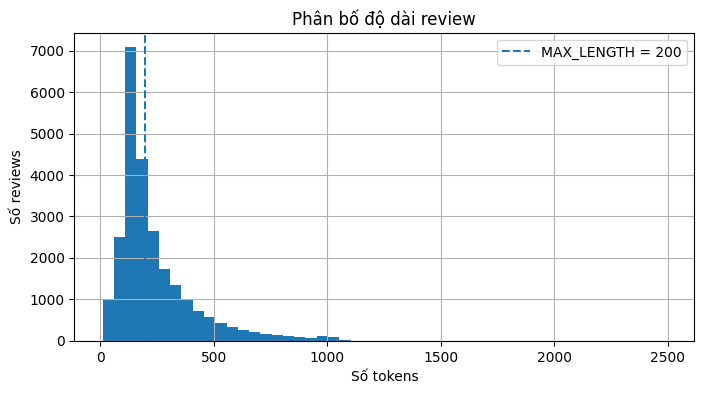

In [ ]:
train_lengths = np.array([len(review) for review in x_train])

print("Min:", train_lengths.min())
print("Mean:", train_lengths.mean())
print("Median:", np.median(train_lengths))
print("Max:", train_lengths.max())

plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=50)
plt.axvline(
    MAX_LENGTH,
    linestyle="--",
    label=f"MAX_LENGTH = {MAX_LENGTH}",
)
plt.xlabel("Số tokens")
plt.ylabel("Số reviews")
plt.title("Phân bố độ dài review")
plt.legend()
plt.grid(True)
plt.show()

## 8. Giải mã word IDs thành văn bản

Các ID đặc biệt:

| ID | Ý nghĩa |
|---:|---|
| 0 | Padding |
| 1 | Start token |
| 2 | Unknown word |
| 3 | Unused |

In [ ]:
word_index = imdb.get_word_index()

reverse_word_index = {
    index + 3: word
    for word, index in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"


def decode_review(sequence):
    return " ".join(
        reverse_word_index.get(int(word_id), "<UNK>")
        for word_id in sequence
    )


print("Nhãn:", y_train[0])
print(decode_review(x_train[0])[:1500])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Nhãn: 1
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but

## 9. Padding và truncation

Mỗi review được đưa về đúng 200 tokens.

```text
[5, 8, 2]
        ↓
[0, 0, 0, 5, 8, 2]
```

`mask_zero=True` trong Embedding giúp RNN bỏ qua padding ID 0.

In [ ]:
from keras.utils import pad_sequences

x_train_padded = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="pre",
    truncating="pre",
    value=0,
)

x_test_padded = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="pre",
    truncating="pre",
    value=0,
)

print("Train shape:", x_train_padded.shape)
print("Test shape:", x_test_padded.shape)

Train shape: (25000, 200)
Test shape: (25000, 200)


## 10. Chia validation set

- Training set: cập nhật weights.
- Validation set: theo dõi trong lúc training.
- Test set: đánh giá cuối.

In [ ]:
indices = np.arange(len(x_train_padded))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

validation_size = int(
    len(indices) * VALIDATION_FRACTION
)

validation_indices = indices[:validation_size]
training_indices = indices[validation_size:]

x_training = x_train_padded[training_indices]
y_training = y_train[training_indices]

x_validation = x_train_padded[validation_indices]
y_validation = y_train[validation_indices]

print("Training:", x_training.shape)
print("Validation:", x_validation.shape)
print("Test:", x_test_padded.shape)

Training: (20000, 200)
Validation: (5000, 200)
Test: (25000, 200)


## 11. Xây dựng model

```text
Input IDs:     (batch, 200)
Embedding:     (batch, 200, 64)
SimpleRNN:     (batch, 64)
Dense sigmoid: (batch, 1)
```

In [ ]:
model = keras.Sequential(
    [
        keras.Input(
            shape=(MAX_LENGTH,),
            dtype="int32",
        ),
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="embedding",
        ),
        layers.SimpleRNN(
            RNN_UNITS,
            name="simple_rnn",
        ),
        layers.Dropout(0.30),
        layers.Dense(
            1,
            activation="sigmoid",
            name="sentiment_output",
        ),
    ],
    name="imdb_simple_rnn",
)

model.summary()

Model: "imdb_simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Compile model

Binary cross-entropy:

$$
L = -[y\log(p) + (1-y)\log(1-p)]
$$

Adam được dùng vì dễ cấu hình cho người mới.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy")
    ],
)

## 13. Callbacks

In [ ]:
MODEL_PATH = "/content/imdb_simple_rnn.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
    ),
]

## 14. Huấn luyện

In [ ]:
history = model.fit(
    x_training,
    y_training,
    validation_data=(
        x_validation,
        y_validation,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.6557 - loss: 0.6202 - val_accuracy: 0.7766 - val_loss: 0.4883 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7847 - loss: 0.4668 - val_accuracy: 0.8114 - val_loss: 0.4619 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8927 - loss: 0.2690 - val_accuracy: 0.8286 - val_loss: 0.4852 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9363 - loss: 0.1717 - val_accuracy: 0.8232 - val_loss: 0.5058 - learning_rate: 5.0000e-04


## 15. Learning curves

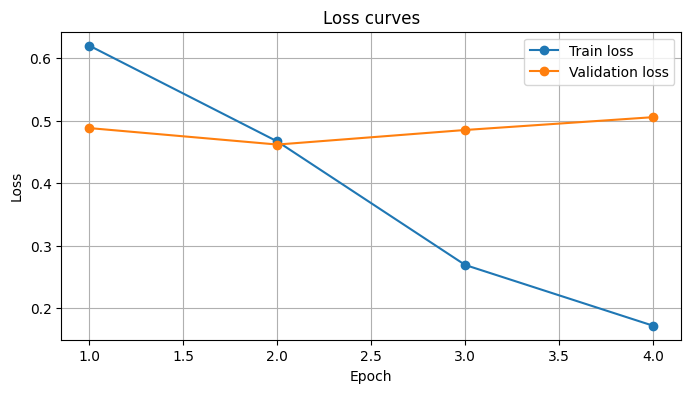

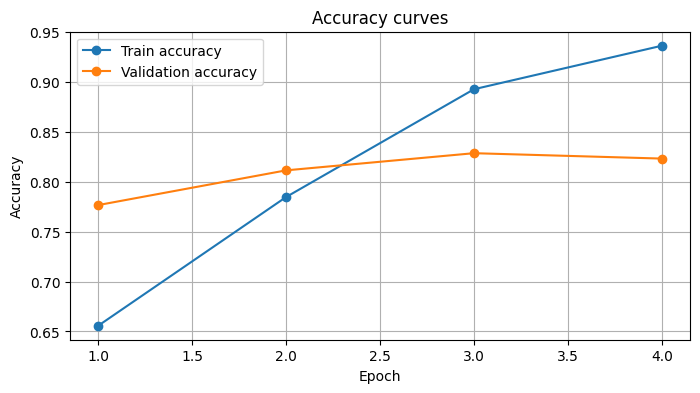

In [ ]:
epochs_axis = range(
    1,
    len(history.history["loss"]) + 1,
)

plt.figure(figsize=(8, 4))
plt.plot(
    epochs_axis,
    history.history["loss"],
    marker="o",
    label="Train loss",
)
plt.plot(
    epochs_axis,
    history.history["val_loss"],
    marker="o",
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    epochs_axis,
    history.history["accuracy"],
    marker="o",
    label="Train accuracy",
)
plt.plot(
    epochs_axis,
    history.history["val_accuracy"],
    marker="o",
    label="Validation accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.grid(True)
plt.show()

## 16. Đánh giá test set

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test_padded,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=1,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7938 - loss: 0.4884
Test loss: 0.4884
Test accuracy: 0.7938


## 17. Confusion Matrix, Precision, Recall và F1

$$
Precision = \frac{TP}{TP+FP}
$$

$$
Recall = \frac{TP}{TP+FN}
$$

$$
F1 = \frac{2PR}{P+R}
$$

In [ ]:
test_probabilities = model.predict(
    x_test_padded,
    batch_size=BATCH_SIZE,
    verbose=0,
).reshape(-1)

test_predictions = (
    test_probabilities >= 0.5
).astype(np.int32)

tn = int(np.sum((y_test == 0) & (test_predictions == 0)))
fp = int(np.sum((y_test == 0) & (test_predictions == 1)))
fn = int(np.sum((y_test == 1) & (test_predictions == 0)))
tp = int(np.sum((y_test == 1) & (test_predictions == 1)))

confusion_matrix = np.array(
    [
        [tn, fp],
        [fn, tp],
    ]
)

precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(
    precision + recall,
    1e-12,
)

print("Confusion matrix:")
print(confusion_matrix)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Confusion matrix:
[[10797  1703]
 [ 3451  9049]]
Precision: 0.8416
Recall:    0.7239
F1-score: 0.7783


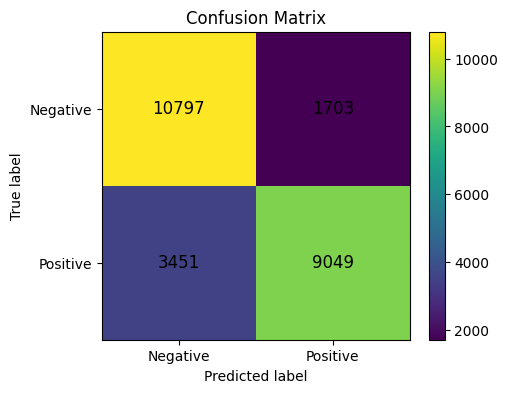

In [ ]:
plt.figure(figsize=(5, 4))
plt.imshow(confusion_matrix)
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            confusion_matrix[row, column],
            ha="center",
            va="center",
            fontsize=12,
        )

plt.colorbar()
plt.show()

## 18. Xem một số prediction

In [ ]:
for index in range(5):
    probability = float(test_probabilities[index])
    prediction = int(probability >= 0.5)

    print("=" * 80)
    print("True label:", int(y_test[index]))
    print("Predicted label:", prediction)
    print("Positive probability:", round(probability, 4))
    print(decode_review(x_test[index])[:800])

True label: 0
Predicted label: 0
Positive probability: 0.2005
<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss
True label: 1
Predicted label: 1
Positive probability: 0.9658
<START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances <UNK> the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an atmosphere <UNK> with sexual tension and psychological <UNK> it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident here a

## 19. Dự đoán câu mới

Đây là tokenizer đơn giản để minh họa. Nó không hoàn toàn giống preprocessing
gốc của IMDB.

In [ ]:
def simple_tokenize(text):
    return re.findall(
        r"[a-z']+",
        text.lower(),
    )


def encode_text(text):
    sequence = [1]

    for token in simple_tokenize(text):
        original_index = word_index.get(token)

        if (
            original_index is None
            or original_index + 3 >= VOCAB_SIZE
        ):
            sequence.append(2)
        else:
            sequence.append(original_index + 3)

    return pad_sequences(
        [sequence],
        maxlen=MAX_LENGTH,
        padding="pre",
        truncating="pre",
        value=0,
    )


def predict_sentiment(text):
    encoded = encode_text(text)

    probability = float(
        model.predict(encoded, verbose=0)[0, 0]
    )

    return {
        "label": (
            "positive"
            if probability >= 0.5
            else "negative"
        ),
        "positive_probability": probability,
    }

In [ ]:
examples = [
    "This movie was wonderful and the acting was excellent.",
    "The film was boring, slow, and a complete waste of time.",
    "The story was simple but I enjoyed the characters.",
]

for text in examples:
    result = predict_sentiment(text)

    print("=" * 70)
    print("Text:", text)
    print("Prediction:", result["label"])
    print(
        "Positive probability:",
        round(result["positive_probability"], 4),
    )

Text: This movie was wonderful and the acting was excellent.
Prediction: positive
Positive probability: 0.8795
Text: The film was boring, slow, and a complete waste of time.
Prediction: negative
Positive probability: 0.0291
Text: The story was simple but I enjoyed the characters.
Prediction: positive
Positive probability: 0.8729


## 20. Lưu và nạp model

In [ ]:
model.save(MODEL_PATH)

loaded_model = keras.models.load_model(
    MODEL_PATH
)

loaded_loss, loaded_accuracy = loaded_model.evaluate(
    x_test_padded,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0,
)

print("Loaded model accuracy:", loaded_accuracy)

Loaded model accuracy: 0.7938399910926819


## 21. Bài tập mở rộng

1. Thay `SimpleRNN` bằng `GRU`.
2. Thay `SimpleRNN` bằng `LSTM`.
3. Dùng `Bidirectional`.
4. So sánh `MAX_LENGTH` 100, 200 và 400.
5. So sánh embedding dimension 32, 64 và 128.
6. Thử dropout 0.0, 0.3 và 0.5.
7. Thử threshold 0.4, 0.5 và 0.6.
8. Tìm các review model dự đoán sai nhưng confidence cao.